In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

In [3]:
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

In [4]:
train_df = pd.read_csv('./archive/train.csv')
val_df = pd.read_csv('./archive/val.csv')

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [5]:
train_df['category'].unique()

array([0, 1, 2])

In [6]:
print(train_df.shape, val_df.shape)

(1034, 2) (133, 2)


In [7]:
print(train_df['category'].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [9]:
class CustomImageDataset(Dataset):
    def __init__(self, df, transform, root_dir='./archive'):
        self.df = df
        self.transform = transform
        self.labels = torch.tensor(df["category"]).to(device)
        self.root_dir = root_dir
    
    def __len__(self):
        return self.df.shape[0]
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx, 0])
        label = self.labels[idx]
        image = Image.open(img_path)
        if self.transform:
            image = (self.transform(image)/255.0).to(device)
    
        return image, label

In [10]:
train_dataset = CustomImageDataset(df=train_df, transform=transform)
val_dataset = CustomImageDataset(df=val_df, transform=transform)

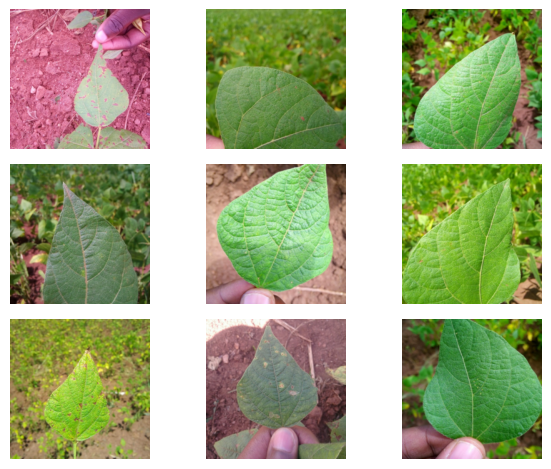

In [11]:
n_rows=3
n_cols=3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
        axarr[row, col].imshow((image*255.0).squeeze().permute(1,2,0))
        axarr[row, col].axis('off')
plt.tight_layout()
plt.show()

In [34]:
LR = 0.001
BATCH_SIZE = 4
epochs = 15

In [35]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [36]:
googlenet_model = models.googlenet(weights='DEFAULT')

In [37]:
for param in googlenet_model.parameters():
    param.requires_grad=True    # If false we can add layers to the pretrained model

In [38]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [39]:
num_classes = len(train_df['category'].unique())
num_classes

3

In [ ]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [41]:
from torchsummary import summary
summary(googlenet_model, input_size=(3, 225, 225))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 113, 113]           9,408
       BatchNorm2d-2         [-1, 64, 113, 113]             128
       BasicConv2d-3         [-1, 64, 113, 113]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
       BasicConv2d-7           [-1, 64, 56, 56]               0
            Conv2d-8          [-1, 192, 56, 56]         110,592
       BatchNorm2d-9          [-1, 192, 56, 56]             384
      BasicConv2d-10          [-1, 192, 56, 56]               0
        MaxPool2d-11          [-1, 192, 28, 28]               0
           Conv2d-12           [-1, 64, 28, 28]          12,288
      BatchNorm2d-13           [-1, 64, 28, 28]             128
      BasicConv2d-14           [-1, 64,

In [42]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [43]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = googlenet_model(inputs)
        train_loss = loss_fun(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
        total_acc_train += train_acc
        optimizer.step()
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100, 4))
    print(f"Epoch {epoch+1}/{epochs}, Train Loss; {round(total_loss_train/1000, 4)}, Train Acc: {round(total_acc_train/train_dataset.__len__()*100, 4)}")

Epoch 1/15, Train Loss; 0.217, Train Acc: 62.5725
Epoch 2/15, Train Loss; 0.192, Train Acc: 69.8259
Epoch 3/15, Train Loss; 0.15, Train Acc: 77.2727
Epoch 4/15, Train Loss; 0.1458, Train Acc: 77.5629
Epoch 5/15, Train Loss; 0.128, Train Acc: 79.4971
Epoch 6/15, Train Loss; 0.1282, Train Acc: 80.9478
Epoch 7/15, Train Loss; 0.1078, Train Acc: 84.4294
Epoch 8/15, Train Loss; 0.0932, Train Acc: 86.6538
Epoch 9/15, Train Loss; 0.0889, Train Acc: 86.6538
Epoch 10/15, Train Loss; 0.1041, Train Acc: 83.1721
Epoch 11/15, Train Loss; 0.0848, Train Acc: 88.3946
Epoch 12/15, Train Loss; 0.089, Train Acc: 87.3308
Epoch 13/15, Train Loss; 0.0763, Train Acc: 87.234
Epoch 14/15, Train Loss; 0.0692, Train Acc: 88.588
Epoch 15/15, Train Loss; 0.0765, Train Acc: 87.911


In [44]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for input, labels in val_loader:
        prediction = googlenet_model(input)

        acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
        total_acc_test += acc

In [45]:
print(round(total_acc_test/val_dataset.__len__()*100, 2))

67.67


# Transfer Learning

In [47]:
for param in googlenet_model.parameters():
    param.requires_grad = False

googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc.requires_grad = True
googlenet_model.fc.to(device)

Linear(in_features=1024, out_features=3, bias=True)

In [48]:
loss_fun = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(epochs):
    total_acc_train = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = googlenet_model(inputs)
        train_loss = loss_fun(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
        total_acc_train += train_acc
        optimizer.step()
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/train_dataset.__len__()*100, 4))
    print(f"Epoch {epoch+1}/{epochs}, Train Loss; {round(total_loss_train/1000, 4)}, Train Acc: {round(total_acc_train/train_dataset.__len__()*100, 4)}")

Epoch 1/15, Train Loss; 0.104, Train Acc: 85.1064
Epoch 2/15, Train Loss; 0.0612, Train Acc: 91.0058
Epoch 3/15, Train Loss; 0.0613, Train Acc: 91.3926
Epoch 4/15, Train Loss; 0.0586, Train Acc: 90.9091
Epoch 5/15, Train Loss; 0.0521, Train Acc: 92.3598
Epoch 6/15, Train Loss; 0.0514, Train Acc: 92.2631
Epoch 7/15, Train Loss; 0.0523, Train Acc: 91.9729
Epoch 8/15, Train Loss; 0.0539, Train Acc: 91.2959
Epoch 9/15, Train Loss; 0.043, Train Acc: 93.617
Epoch 10/15, Train Loss; 0.0521, Train Acc: 92.7466
Epoch 11/15, Train Loss; 0.0456, Train Acc: 93.1335
Epoch 12/15, Train Loss; 0.0482, Train Acc: 93.0368
Epoch 13/15, Train Loss; 0.0538, Train Acc: 92.0696
Epoch 14/15, Train Loss; 0.0535, Train Acc: 91.1025
Epoch 15/15, Train Loss; 0.055, Train Acc: 92.3598
